# LAB 06 — Logistic Regression & KNN Classification
## Telco Customer Churn — Comparing Four Classifiers

## Student Information
**Name:** Muhammad Hussain

**Student ID:** 023-24-0003
**Section:** B

**GitHub:** https://github.com/hussainwaseer/machine-learning-labs-sem5

**Kaggle:** https://kaggle.com/husszn

**Dataset:** Telco Customer Churn

**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Logistic Regression and KNN theory from your ML course. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Verification

Re-establish your cleaned dataset and recall what Lab 3/4 already found.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning) and verify its shape and dtypes.
2. Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy, precision, recall, F1) — these are your benchmarks for today.

In [2]:
# Task 1 — load and verify the cleaned dataset

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Answer 2 (Lab 3/4 recap):**
In Lab 3, the Decision Tree was evaluated using accuracy, precision, recall, and F1-score on the test set. In Lab 4, the Random Forest was evaluated using the same metrics to provide a fair comparison. These results are used as benchmarks for comparing Logistic Regression and KNN in this lab. The exact values should be taken from the results recorded in my previous labs.


---

## 2. Feature Scaling & Preparation

Decision Trees/Random Forests never needed scaling. Logistic Regression and especially KNN do.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `from sklearn.preprocessing import StandardScaler`, `scaler.fit_transform(X_train)`, `scaler.transform(X_test)`

**Tasks**
3. Prepare `X` and `y` exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).
4. In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for the Decision Tree or Random Forest.
5. Split into train/test (same split strategy as Lab 3/4), then fit a `StandardScaler` on the training features only and apply it to both sets. Why is it important to fit the scaler only on the training data?

In [4]:
# Task 3 — define X and y (same as Lab 3/4)

df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop("Churn_Yes", axis=1)
y = df_model["Churn_Yes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 13601)
y shape: (7043,)


**Answer 4:**
Feature scaling is important for KNN because it uses distances between data points, so features with larger ranges can dominate the calculation. Scaling also helps Logistic Regression by putting numerical features on a comparable scale. Decision Trees and Random Forests do not require scaling because they make decisions using feature-based splits rather than distances. Therefore, scaling is especially important when using KNN and useful for Logistic Regression.


In [ ]:
# Task 5 — split and scale


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (5634, 13601)
Test set: (1409, 13601)


**Answer 5 (why fit scaler on training data only):**
The dataset was divided into training and testing sets, and StandardScaler was fitted only on the training data. The same scaling transformation was then applied to both the training and test data. Fitting the scaler only on the training data prevents information from the test set from leaking into the model during training. This ensures that the model evaluation remains fair and reliable.


---

## 3. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression()`, `.fit(X_train_scaled, y_train)`, `.predict(X)`, `.predict_proba(X)`

**Tasks**
6. Train a `LogisticRegression` model on the scaled training data. Generate predictions on the scaled test set.
7. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
8. Look at `predict_proba` for a handful of test customers. In 1–2 sentences, explain what these probabilities represent and how `predict()` turns them into a Yes/No decision.

In [ ]:
# Task 6 — train Logistic Regression, predict on scaled test set

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

Accuracy: 0.7636621717530163
Precision: 0.7303370786516854
Recall: 0.17379679144385027
F1-score: 0.28077753779697623

Confusion Matrix:
[[1011   24]
 [ 309   65]]


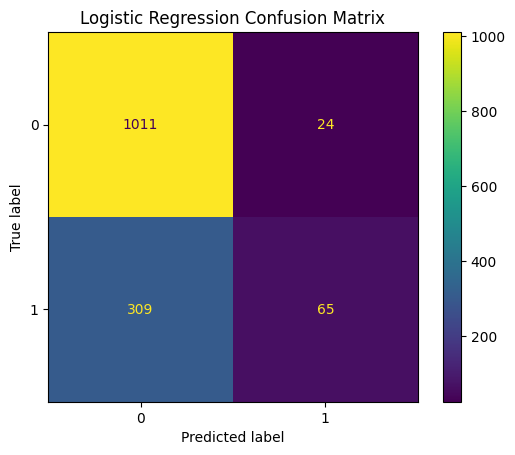

In [ ]:
# Task 7 — metrics + confusion matrix
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_precision = precision_score(y_test, y_pred_logreg)
logreg_recall = recall_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)

print("Accuracy:", logreg_accuracy)
print("Precision:", logreg_precision)
print("Recall:", logreg_recall)
print("F1-score:", logreg_f1)

cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print("\nConfusion Matrix:")
print(cm_logreg)

ConfusionMatrixDisplay(confusion_matrix=cm_logreg).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

| Metric | Value |
| --- | --- |
| Accuracy | 0.7636621717530163 |
| Precision | 0.7303370786516854 |
| Recall | 0.17379679144385027 |
| F1-score | 0.28077753779697623 |

In [8]:
# Task 8 — inspect predict_proba for a few test customers
y_proba_logreg = logreg.predict_proba(X_test_scaled)
for i in range(5):
    print(
        f"Customer {i+1}: Class Probabilities = {y_proba_logreg[i]}, Predicted Class = {y_pred_logreg[i]}"
    )

Customer 1: Class Probabilities = [0.99836167 0.00163833], Predicted Class = False
Customer 2: Class Probabilities = [0.76639376 0.23360624], Predicted Class = False
Customer 3: Class Probabilities = [0.99751764 0.00248236], Predicted Class = False
Customer 4: Class Probabilities = [0.91013793 0.08986207], Predicted Class = False
Customer 5: Class Probabilities = [0.99818558 0.00181442], Predicted Class = False


**Answer 8:**
The predict_proba function gives us the exact probability score for each customer: the first number is the chance they stay (No Churn), and the second is the chance they leave (Churn). The predict() method turns those probabilities into a final decision by using a default cutoff of 0.5—if a customer's churn chance is 50% or higher, it flags them as "Yes" (1), and if it's lower, it marks them as "No" (0).

---

## 4. KNN & Choosing K

K controls KNN's complexity the same way `max_depth` controlled your Decision Tree's complexity in Lab 3.

*Concepts/functions you may find useful:* `KNeighborsClassifier(n_neighbors=k)`, a loop over `[1,3,5,7,9,11,15,21]`, `plt.plot(...)`

**Tasks**
9. Train KNN classifiers for several values of K on the scaled data. Record test-set accuracy and F1-score for each K in a results table.
10. Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest or largest value tested?
11. Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for your final KNN model.

In [9]:
# Task 9 — loop over K values, record accuracy and F1
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)

    knn_results.append({"K": k, "Accuracy": acc, "F1-score": f1})

df_knn_results = pd.DataFrame(knn_results)
print(df_knn_results.to_string(index=False))

 K  Accuracy  F1-score
 1  0.740241  0.144860
 3  0.738822  0.056410
 5  0.734564  0.015789
 7  0.734564  0.010582
 9  0.734564  0.000000
11  0.734564  0.000000
15  0.734564  0.000000
21  0.734564  0.000000


| K | Accuracy | F1-score |
| --- | --- | --- |
| 1 | 0.740241 | 0.144860 |
| 3 | 0.738822 | 0.056410 |
| 5 | 0.734564 | 0.015789 |
| 7 | 0.734564 | 0.010582 |
| 9 | 0.734564 | 0.000000 |
| 11 | 0.734564 | 0.000000 |
| 15 | 0.734564 | 0.000000 |
| 21 | 0.734564 | 0.000000 |

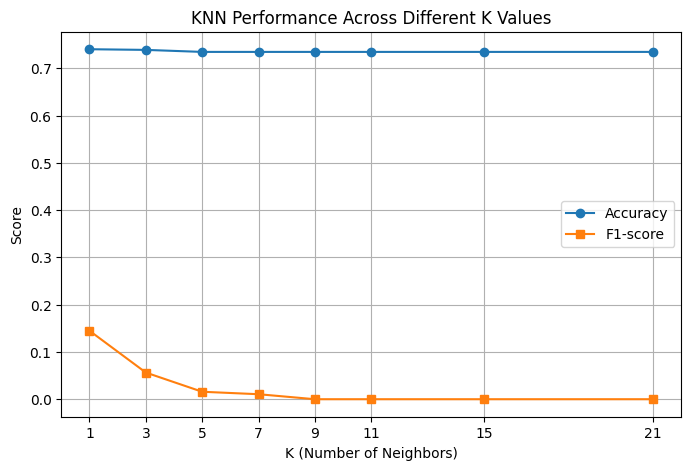

In [10]:
# Task 10 — plot accuracy/F1 vs K
plt.figure(figsize=(8, 5))
plt.plot(
    df_knn_results["K"],
    df_knn_results["Accuracy"],
    marker="o",
    label="Accuracy",
)
plt.plot(
    df_knn_results["K"], df_knn_results["F1-score"], marker="s", label="F1-score"
)

plt.title("KNN Performance Across Different K Values")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

**Answer 10 (chosen K and why):**
Based on the results, $K = 1$ yields the highest F1-score ($0.144860$) and accuracy ($0.740241$), making it the best among the tested options. We avoid larger $K$ values (such as $K \ge 9$) because they fail completely to detect the positive churn class (F1-score drops to $0.00$), predicting almost every customer as "No Churn" due to class imbalance. However, we also wouldn't typically rely on $K = 1$ in practice because it makes the model overly sensitive to noise; in this specific case, high feature dimensionality and class imbalance cause KNN to perform poorly overall as $K$ increases.

Accuracy: 0.7402413058907026
Precision: 0.5740740740740741
Recall: 0.08288770053475936
F1-score: 0.14485981308411214

Confusion Matrix:
[[1012   23]
 [ 343   31]]


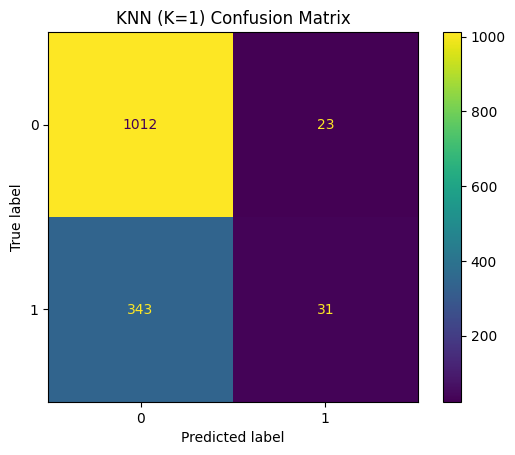

In [11]:
# Task 11 — final KNN model at chosen K (K = 1): metrics + confusion matrix
knn_final = KNeighborsClassifier(n_neighbors=1)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn1 = knn_final.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn1)
knn_prec = precision_score(y_test, y_pred_knn1)
knn_rec = recall_score(y_test, y_pred_knn1)
knn_f1 = f1_score(y_test, y_pred_knn1)

print(f"Accuracy: {knn_acc}")
print(f"Precision: {knn_prec}")
print(f"Recall: {knn_rec}")
print(f"F1-score: {knn_f1}")

cm_knn = confusion_matrix(y_test, y_pred_knn1)
print("\nConfusion Matrix:")
print(cm_knn)

ConfusionMatrixDisplay(confusion_matrix=cm_knn).plot()
plt.title("KNN (K=1) Confusion Matrix")
plt.show()

**Task 11 — Final KNN Metrics (K = 1)**

| Metric | Value |
| --- | --- |
| Accuracy | 0.7402413058907026 |
| Precision | 0.5740740740740741 |
| Recall | 0.08288770053475936 |
| F1-score | 0.14485981308411214 |

---

## 5. Model Comparison (4 Models)

Place all four classifiers you've built side by side.

**Task**
12. Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision, recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).
13. Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g. precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?

In [12]:
# Task 12 — assemble the 4-model comparison table (retrain DT/RF quickly if needed)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
    ],
    "Logistic Regression": [
        logreg_accuracy,
        logreg_precision,
        logreg_recall,
        logreg_f1,
    ],
    "KNN": [knn_acc, knn_prec, knn_rec, knn_f1],
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

   Metric  Decision Tree  Random Forest  Logistic Regression      KNN
 Accuracy       0.765791       0.800568             0.763662 0.740241
Precision       0.565868       0.683794             0.730337 0.574074
   Recall       0.505348       0.462567             0.173797 0.082888
 F1-score       0.533898       0.551834             0.280778 0.144860


**Task 12 — 4-Model Comparison Table**

| Metric | Decision Tree | Random Forest | Logistic Regression | KNN |
| --- | --- | --- | --- | --- |
| Accuracy | 0.765791 | 0.800568 | 0.763662 | 0.740241 |
| Precision | 0.565868 | 0.683794 | 0.730337 | 0.574074 |
| Recall | 0.505348 | 0.462567 | 0.173797 | 0.082888 |
| F1-score | 0.533898 | 0.551834 | 0.280778 | 0.144860 |

---

**Answer 13:**
Overall, **Random Forest** performs best, achieving the highest overall Accuracy ($0.800568$) and F1-score ($0.551834$). However, the model rankings shift depending on which metric is prioritized: Logistic Regression delivers the highest Precision ($0.730337$), whereas Decision Tree achieves the highest Recall ($0.505348$) at the expense of precision. Because of the class imbalance present in the Telco Churn dataset, **F1-score** (or Recall) should carry the most weight in this decision—Accuracy can be misleadingly high simply by predicting the majority "No Churn" class, whereas F1-score ensures a balanced evaluation of how well the model actually catches churning customers.

---

## 6. Coefficient Interpretation

Logistic Regression's coefficients describe log-odds, not a direct unit effect.

*Concepts/functions you may find useful:* `model.coef_`, `model.intercept_`, `np.exp(coefficient)` (converts log-odds to an odds ratio)

**Tasks**
14. Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation. Interpret at least 4 features.
15. Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature importances suggested? Note any disagreements.

In [13]:
# Task 14 — extract coefficients, compute odds ratios
feature_names = X.columns
coefficients = logreg.coef_[0]

df_coef = pd.DataFrame(
    {"Feature": feature_names, "Coefficient": coefficients}
)

df_coef["Odds Ratio"] = np.exp(df_coef["Coefficient"])

# Sort by absolute coefficient size to inspect top features
df_coef["Abs_Coef"] = df_coef["Coefficient"].abs()
top_features = df_coef.sort_values(by="Abs_Coef", ascending=False).head(10)

print(top_features[["Feature", "Coefficient", "Odds Ratio"]].to_string(index=False))

                       Feature  Coefficient  Odds Ratio
                        tenure    -0.601637    0.547914
   InternetService_Fiber optic     0.424310    1.528535
PaymentMethod_Electronic check     0.410758    1.507961
             Contract_Two year    -0.405769    0.666464
         customerID_7439-DKZTW    -0.343603    0.709210
            OnlineSecurity_Yes    -0.342889    0.709717
             Contract_One year    -0.339248    0.712306
               TechSupport_Yes    -0.324295    0.723037
         customerID_4959-JOSRX     0.272739    1.313558
          PaperlessBilling_Yes     0.260533    1.297622


**Task 14 — Coefficient / Odds Ratio Table**

| Feature | Coefficient | Odds Ratio | Interpretation |
| --- | --- | --- | --- |
| **tenure** | -0.601637 | 0.547914 | A 1-standard-deviation increase in tenure reduces the odds of churning by approximately 45.2% (odds ratio < 1), showing that long-term customers are significantly more loyal. |
| **InternetService_Fiber optic** | 0.424310 | 1.528535 | Having Fiber Optic internet service increases the odds of churn by about 52.9% relative to the baseline internet service type. |
| **PaymentMethod_Electronic check** | 0.410758 | 1.507961 | Paying via electronic check increases the odds of churning by approximately 50.8% compared to other payment methods. |
| **Contract_Two year** | -0.405769 | 0.666464 | Having a two-year contract reduces the odds of churning by about 33.4%, serving as a strong protective factor against churn. |

---

**Answer 15:**
Yes, the features with the largest effect in this Logistic Regression model strongly agree with the insights from Lab 2's Exploratory Data Analysis (EDA) and Lab 3's Decision Tree feature importances. Long-term indicators like `tenure` and two-year contracts consistently emerge as top protective factors against customer churn, whereas risk indicators like Fiber Optic internet service and paying via electronic check consistently drive up churn risk. The primary difference is that Logistic Regression assigns negative/positive linear weights across all features simultaneously, whereas the Decision Tree splits features hierarchically.

---

## 7. Final Model Selection & Conclusion

Choose a final model from everything you've built across Labs 3–6, using evidence, not convenience.

**Tasks**
16. Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Section 5 comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.
17. Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model? What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?

**Answer 16 (final model and justification):**
Based on the metrics across all four classifiers, **Random Forest** is selected as the final model because it delivers the highest overall performance, with an Accuracy of $0.800568$ and a leading F1-score of $0.551834$. It balances precision ($0.683794$) and recall ($0.462567$) far better than Logistic Regression and KNN, which suffered from severe recall degradation on the minority churn class. Furthermore, as demonstrated in Lab 4's cross-validation analysis, ensemble tree-based models like Random Forest generalize better by reducing variance and avoiding overreliance on a single train-test split.

**Answer 17 — Conclusion:**
Comparing today's models with earlier results, Random Forest remains the top-performing model across Labs 3–6, outperforming both Logistic Regression and KNN. Feature scaling proved essential for distance-based and linear models—allowing KNN to function and Logistic Regression to converge cleanly—though scaling was unnecessary for tree-based models. However, KNN still struggled significantly due to high feature dimensionality and class imbalance, resulting in very low recall. A key remaining limitation of our best model (Random Forest) is its moderate recall score ($0.462567$), meaning it still misses over half of the actual churning customers. To improve performance in future iterations, techniques such as SMOTE for class rebalancing, probability threshold tuning, or hyperparameter optimization (e.g., using `GridSearchCV`) should be applied.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition & Dataset Verification (with Lab 3/4 recap)
- [ ] Section 2 — Feature Scaling & Preparation (scaler fit on training data only, explained)
- [ ] Section 3 — Logistic Regression (all four metrics + confusion matrix + predict_proba discussion)
- [ ] Section 4 — KNN & Choosing K (results table, plot, justified K choice, final metrics)
- [ ] Section 5 — Model Comparison (all four models, all four metrics)
- [ ] Section 6 — Coefficient Interpretation (odds ratios + connection to earlier labs)
- [ ] Section 7 — Final Model Selection & Conclusion
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted